Here we are going to find the Number of customers who left the company and what is the trend

checking items:

1.What % of customers churn?

2.Which contract type churns most?

3.Does higher monthly charge increase churn?

4.Does tenure affect churn?

##Preprocessing of dataset

In [3]:
import pandas as pd 

df = pd.read_excel('/Users/anupamkajith/Desktop/MLprojects/Telco_customer_churn.xlsx')

In [4]:
df.shape

(7043, 33)

In [5]:
# replacing null values with NA
df.replace(" ",pd.NA, inplace = True)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [6]:
#convert total changes to numeric
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

df.shape
#dropped the null values:

(7043, 33)

In [7]:
df.shape
#check duplicates
#df.duplicated().sum()

(7043, 33)

In [8]:
#the coloumn names blank space should be removed
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ","_")

In [9]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip_Code',
       'Lat_Long', 'Latitude', 'Longitude', 'Gender', 'Senior_Citizen',
       'Partner', 'Dependents', 'Tenure_Months', 'Phone_Service',
       'Multiple_Lines', 'Internet_Service', 'Online_Security',
       'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV',
       'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method',
       'Monthly_Charges', 'Total_Charges', 'Churn_Label', 'Churn_Value',
       'Churn_Score', 'CLTV', 'Churn_Reason'],
      dtype='str')

In [10]:
df['Total_Charges'].isnull().sum()

np.int64(11)

In [11]:
# check unique value to understand the categorical structure of the dataset
df['Churn_Label'].value_counts()

Churn_Label
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [13]:
df['churn'] = df['Churn_Label'].map({'Yes':1,'No':0})

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip_Code           7043 non-null   int64  
 6   Lat_Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior_Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure_Months      7043 non-null   int64  
 14  Phone_Service      7043 non-null   str    
 15  Multiple_Lines     7043 non-null   str    
 16  Internet_Service   7043 non-null   

#Now we start the real analysis

In [15]:
df['Churn_Label'].value_counts(normalize=True) *100

Churn_Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

From now on:

Any segment with churn rate > 26.5% = High Risk
Any segment with churn rate < 26.5% = Low Risk

In [16]:
df['Tenure_Months'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure_Months, dtype: float64

In [17]:
#Create tenure group
df['Tenure_Group']=pd.cut(df['Tenure_Months'],bins=[0,6,12,24,48,72],labels=['0-6','6-12','12-24','24-48','48-72'])

In [18]:
pd.crosstab(df['Tenure_Group'],df['Churn_Label'],normalize='index') *100

Churn_Label,No,Yes
Tenure_Group,,
0-6,46.666667,53.333333
6-12,64.113475,35.886525
12-24,71.289062,28.710938
24-48,79.611041,20.388959
48-72,90.486824,9.513176


# Point to see: Customers from 0-6 months are more likely to churn so we should prioritize those customers.

In [19]:
pd.crosstab(df['Contract'],df['Churn_Label'],normalize='index')*100

Churn_Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


# Point to take: Month to Month churn rate is more, so comparing with the average churn rate 26.53% the churn rate for month to month is 16% have more percentage point to churn.

Month-to-month customers represent a high-risk segment with churn 16 percentage points above the company average. Retention strategies should prioritize this group.

# what we discovered till now:
1. month to month churn rate is more
2. 0-6 months is the time were churn is more
3. two year contract churn rate is less

-> That mean customers with less contract is at high risk so we should focus on them more.

In [20]:
pd.crosstab(df['Tech_Support'],df['Churn_Label'],normalize='index')*100

Churn_Label,No,Yes
Tech_Support,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


-> This means customers with No Tech support Churn more (15.1% more is the percentage point compared to the average churn rate)

1. providing tech support to customers facing issue retains them.
2. lack of tech support increases dissatisfication


Combining all the insights:
1. 0-6 months churn rate more
2. month to month churn rate more
3. without tech support churn rate more

-> short commintement + low engagement = churn rate

# NEXT TASK:- Are customers who pay more money more likely to leave?

In [21]:
# we group customer based on churn label and find the average of monthly charge of each group
df.groupby('Churn_Label')['Monthly_Charges'].mean()

Churn_Label
No     61.265124
Yes    74.441332
Name: Monthly_Charges, dtype: float64

-> Note, higher paying customer more likely to churn

In [22]:
df['Monthly_Charges_group'] = pd.cut(df['Monthly_Charges'],bins=[0,30,60,90,120],labels=['Low', "Medium", "High", "Very High"])
pd.crosstab(df['Monthly_Charges_group'],df['Churn_Label'],normalize='index')*100



#df['Tenure_Group']=pd.cut(df['Tenure_Months'],bins=[0,6,12,24,48,72],labels=['0-6','6-12','12-24','24-48','48-72'])

Churn_Label,No,Yes
Monthly_Charges_group,,
Low,90.199637,9.800363
Medium,74.071146,25.928854
High,66.093881,33.906119
Very High,67.222542,32.777458


-> customers in High and very high monthly charge are having more churn rate (i.e, 7 percentage points more than averange company churn rate.)

# Finding: Early stage, customers paying high, without proper customer support are more vulnerable to churn

#Now lets combine features

In [23]:
pd.crosstab([df['Tenure_Group'],df['Contract']],df['Churn_Label'],normalize='index')*100

Churn_Label                          No        Yes
Tenure_Group Contract                             
0-6          Month-to-month   44.798301  55.201699
             One year         89.473684  10.526316
             Two year        100.000000   0.000000
6-12         Month-to-month   58.003442  41.996558
             One year         89.411765  10.588235
             Two year        100.000000   0.000000
12-24        Month-to-month   62.279512  37.720488
             One year         91.878173   8.121827
             Two year        100.000000   0.000000
24-48        Month-to-month   67.082294  32.917706
             One year         89.382239  10.617761
             Two year         97.810219   2.189781
48-72        Month-to-month   73.976608  26.023392
             One year         87.066246  12.933754
             Two year         96.674584   3.325416

-> customer churn mainly with Month - to month contract and customers with tenure group of less months is more vulnerable.

In [24]:
#combine tenure group with support

pd.crosstab([df['Contract'],df['Tech_Support']],df['Churn_Label'],normalize='index')*100

Churn_Label                                No        Yes
Contract       Tech_Support                             
Month-to-month No                   49.626866  50.373134
               No internet service  81.106870  18.893130
               Yes                  69.299553  30.700447
One year       No                   85.278276  14.721724
               No internet service  97.527473   2.472527
               Yes                  86.413043  13.586957
Two year       No                   94.067797   5.932203
               No internet service  99.216301   0.783699
               Yes                  96.467722   3.532278

# Customers with month to month contract and no tech support and more vulnerable to churn 

In [25]:
pd.crosstab([df['Tenure_Group'],df['Contract']],df['Churn_Label'],normalize='index')*100

Churn_Label                          No        Yes
Tenure_Group Contract                             
0-6          Month-to-month   44.798301  55.201699
             One year         89.473684  10.526316
             Two year        100.000000   0.000000
6-12         Month-to-month   58.003442  41.996558
             One year         89.411765  10.588235
             Two year        100.000000   0.000000
12-24        Month-to-month   62.279512  37.720488
             One year         91.878173   8.121827
             Two year        100.000000   0.000000
24-48        Month-to-month   67.082294  32.917706
             One year         89.382239  10.617761
             Two year         97.810219   2.189781
48-72        Month-to-month   73.976608  26.023392
             One year         87.066246  12.933754
             Two year         96.674584   3.325416

# customers with 0-6 months tenure group and month to month contract has the highest churn rate and next comes 6 - 12 months group

Customers in their first 6 months on month-to-month contracts exhibit the highest churn risk at 55%, significantly above the company average of 26.5%. Retention strategies should prioritize early engagement and conversion of new month-to-month customers into longer-term contracts.

# Visualization

# # General churn rate

In [26]:
import matplotlib.pyplot as plt

In [34]:
churn_counts = df['Churn_Label'].value_counts(normalize=True)*100

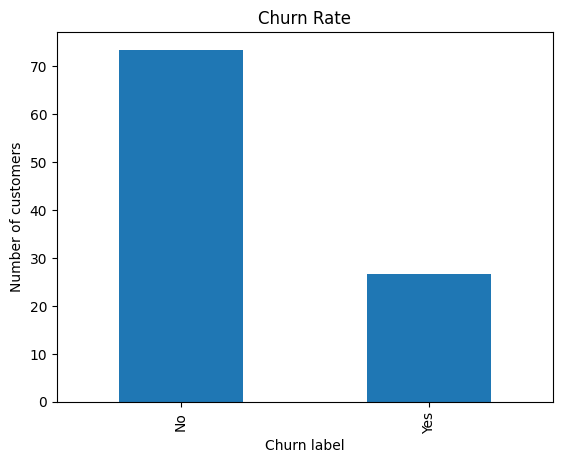

In [35]:
plt.figure()
churn_counts.plot(kind='bar')
plt.title('Churn Rate')
plt.ylabel('Number of customers')
plt.xlabel('Churn label')
plt.show()

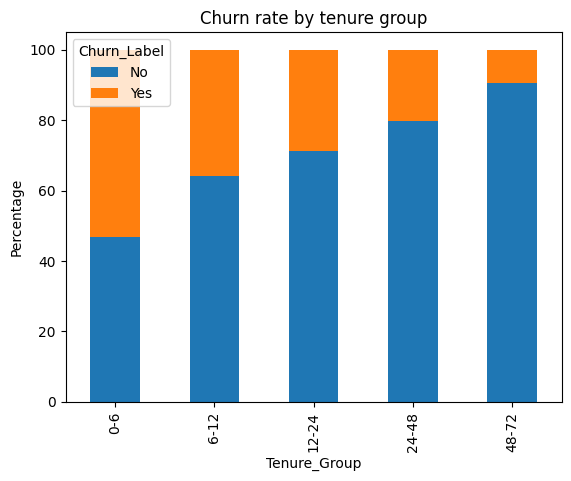

In [ ]:
#Churn  rate as per tenure group 
churn_group = pd.crosstab(df['Tenure_Group'],df['Churn_Label'],normalize='index')*100


churn_group.plot(kind='bar',stacked=True)
plt.title('Churn rate by tenure group')
plt.ylabel('Percentage')
plt.show()

#contract type vs churn

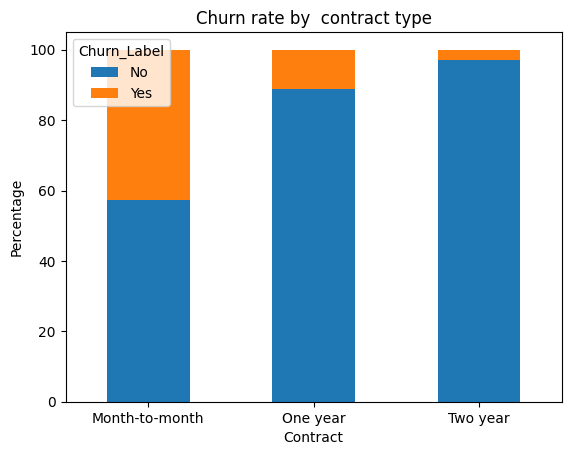

In [40]:
contract_churn = pd.crosstab(df['Contract'],df['Churn_Label'],normalize='index')*100


contract_churn.plot(kind='bar',stacked=True)
plt.title('Churn rate by  contract type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

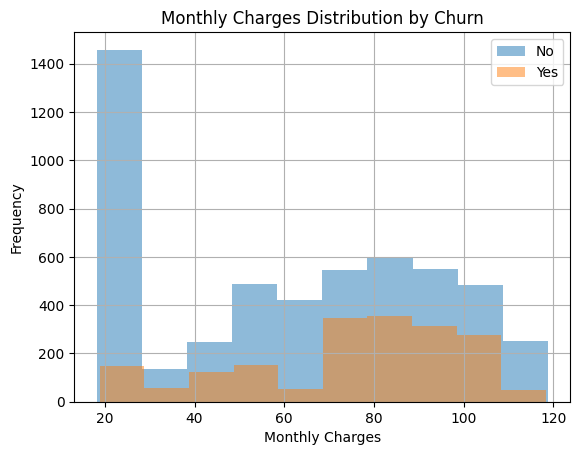

In [42]:
plt.figure()
df[df["Churn_Label"]=="No"]["Monthly_Charges"].hist(alpha=0.5)
df[df["Churn_Label"]=="Yes"]["Monthly_Charges"].hist(alpha=0.5)
plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.legend(["No", "Yes"])
plt.show()